Washing Time : 107.4  minutes  Water Use : 107.4  liter


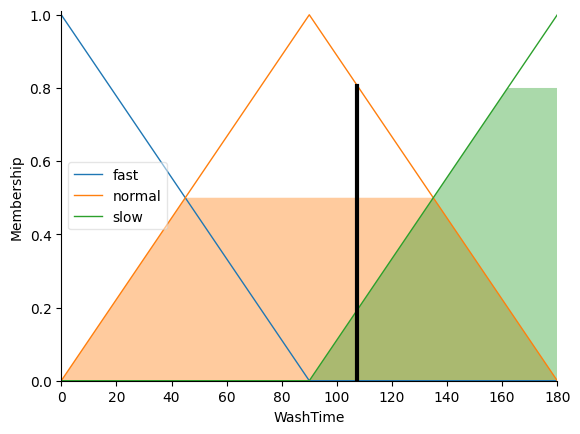

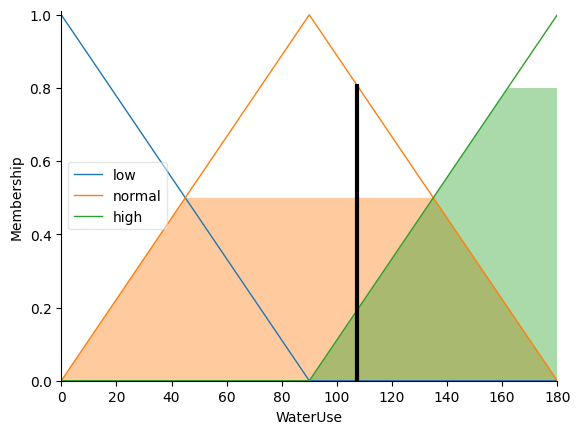

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
Load = ctrl.Antecedent(np.arange(0, 8.1, 0.1), 'Load')
Dirt_Level = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'Dirt_Level')
Fabric_Type = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'Fabric_Type')
WashTime = ctrl.Consequent(np.arange(0, 180.1, 0.1), 'WashTime')
WaterUse = ctrl.Consequent(np.arange(0, 180.1, 0.1), 'WaterUse')
Load['small'] = fuzz.trimf(Load.universe, [0, 0, 4])
Load['average'] = fuzz.trimf(Load.universe, [0, 4, 8])
Load['large'] = fuzz.trimf(Load.universe, [4, 8, 8])
Dirt_Level['low'] = fuzz.trimf(Dirt_Level.universe, [0, 0, 5])
Dirt_Level['normal'] = fuzz.trimf(Dirt_Level.universe, [0, 5, 10])
Dirt_Level['high'] = fuzz.trimf(Dirt_Level.universe, [5, 10, 10])
Fabric_Type['mong'] = fuzz.trimf(Fabric_Type.universe, [0, 0, 5])
Fabric_Type['bthg'] = fuzz.trimf(Fabric_Type.universe, [0, 5, 10])
Fabric_Type['nang'] = fuzz.trimf(Fabric_Type.universe, [5, 10, 10])
WashTime['fast'] = fuzz.trimf(WashTime.universe, [0 ,0, 90])
WashTime['normal'] = fuzz.trimf(WashTime.universe, [0 ,90, 180])
WashTime['slow'] = fuzz.trimf(WashTime.universe, [90, 180, 180])
WaterUse['low'] = fuzz.trimf(WaterUse.universe, [0, 0, 90])
WaterUse['normal'] = fuzz.trimf(WaterUse.universe, [0, 90, 180])
WaterUse['high'] = fuzz.trimf(WaterUse.universe, [90, 180, 180])
rule1 = ctrl.Rule(Load['small'] & Dirt_Level['low'] & Fabric_Type['mong'],(WashTime['fast'], WaterUse['low']))
rule2 = ctrl.Rule(Load['average'] & Dirt_Level['normal'] & Fabric_Type['bthg'],(WashTime['normal'], WaterUse['normal']))
rule34 = ctrl.Rule(Load['large'] & Dirt_Level['high'] & Fabric_Type['nang'],(WashTime['slow'], WaterUse['high']))
rule4 = ctrl.Rule(Dirt_Level['high'],(WashTime['slow'], WaterUse['high']))
rule5 = ctrl.Rule(Load['large'],(WashTime['slow'], WaterUse['high']))
rule6 = ctrl.Rule(Fabric_Type['nang'],(WashTime['slow'], WaterUse['high']))
rule7 = ctrl.Rule(Load['small'] & Dirt_Level['normal'],(WashTime['normal'], WaterUse['normal']))
rule8 = ctrl.Rule(Load['small'] & Fabric_Type['nang'],(WashTime['normal'], WaterUse['normal']))
kq_ctrl = ctrl.ControlSystem([rule1, rule2, rule34, rule4, rule5, rule6, rule7, rule8])
kq = ctrl.ControlSystemSimulation(kq_ctrl)
kq.input['Load'] = 2.0
kq.input['Dirt_Level'] = 8.0
kq.input['Fabric_Type'] = 9.0
kq.compute()
print("Washing Time :", round(kq.output['WashTime'], 1), " minutes"," Water Use :", round(kq.output['WaterUse'], 1), " liter")
WashTime.view(sim= kq)
WaterUse.view(sim= kq)